# Imports and dependencies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import re
import unicodedata
from pathlib import Path
from urllib.parse import urlparse
from io import StringIO
import requests
from transformers import pipeline

# Datasets

In [8]:
df = pd.read_csv("02_processed.csv")
references = pd.read_csv("06a_references.csv", encoding="utf-8-sig")

/tmp/ipykernel_17838/2785057818.py:2: DtypeWarning: Columns (5,6,7,8,9,10,13,14,15,18,19,20,21,22,23,24,25,26,28,29,30,31,32,33,34,35,36,38,39,40,41,42,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,76,77,78,80,82,83,84,85,86,87,88,90,91,92,93,94,95,97,98,99,100,102,103,104,105,107,108,109,110,111,112,113,114,115,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,144,145,146,147,148,149,150,151,152,153,155,156,157,158,159,160,161,162,163,164,166,167,168,169,170,171,172,173,174,175,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,210,211,215,216,217,218,219,220,221,222,223,224,226,227,228,229,230,231,232,233,234,235,237,238,239,240,241,242,243,244,245,246,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,267,270,271,272,273,275,276,277,278,279,280,281,282,283,284,286,287,289,290,292,293,294,295,296,297,299,301,30

# URL classification

In [ ]:
TIPOS_DESCARTAR = {
    "ref_vacia", "texto_libre",
    "harvnb", "harvard_texto", "harvard_wikilink",
    "harvard_inline", "harvard_pagina", "harvtxt", "harvp",
}
references = references[~references["tipo"].isin(TIPOS_DESCARTAR)].copy()

BOOK_TIPOS = {
    "cite_book", "cite_encyclopedia", "cite_encyclopaedia", "cite_dictionary",
    "cite_book_chapter", "cite_ebo", "cite_eb1911", "isbn", "isbn_sin_plantilla",
}

def first_valid(*cols):
    result = pd.Series([pd.NA] * len(references), index=references.index, dtype=object)
    for col in cols:
        if col in references.columns:
            result = result.where(result.notna(), references[col])
    return result

references["article_title"] = references["articulo"]
references["reference_url"] = first_valid("url", "archiveurl")
references["is_book"]       = references["tipo"].isin(BOOK_TIPOS)
references["author"]        = first_valid("last1", "last", "author", "author-last", "author-last1", "author1")
references["book_title"]    = references.get("title",     pd.Series(dtype=object))
references["publisher"]     = references.get("publisher", pd.Series(dtype=object))
references["year"]          = references.get("year",      pd.Series(dtype=object))

/tmp/ipykernel_426/130922583.py:2: DtypeWarning: Columns (5,6,7,8,9,10,13,14,15,18,19,20,21,22,23,24,25,26,28,29,30,31,32,33,34,35,36,38,39,40,41,42,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,76,77,78,80,82,83,84,85,86,87,88,90,91,92,93,94,95,97,98,99,100,102,103,104,105,107,108,109,110,111,112,113,114,115,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,144,145,146,147,148,149,150,151,152,153,155,156,157,158,159,160,161,162,163,164,166,167,168,169,170,171,172,173,174,175,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,210,211,215,216,217,218,219,220,221,222,223,224,226,227,228,229,230,231,232,233,234,235,237,238,239,240,241,242,243,244,245,246,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,267,270,271,272,273,275,276,277,278,279,280,281,282,283,284,286,287,289,290,292,293,294,295,296,297,299,301,302,3

In [ ]:
ARTICLES_TITLES = [
    "Unidentified flying object", "1953 Iranian coup d'état", "1963 South Vietnamese coup d'état",
    "Apartheid", "Armenian genocide", "Cambodian genocide", "Anfal campaign",
    "Native Americans in the United States", "Scientology", "Soviet war crimes",
    "Chris Brown", "Angelina Jolie", "Brad Pitt", "Marilyn Manson", "Ozzy Osbourne",
    "Mikhail Gorbachev", "Saddam Hussein", "Vladimir Lenin", "Karl Marx", "Mother Teresa",
    "Elon Musk", "Andrew Tate", "Vladimir Putin", "Ronald Reagan", "Margaret Thatcher",
    "2003 invasion of Iraq", "Bashar al-Assad", "September 11 attacks", "Tibet",
    "Hezbollah", "Hamas", "Al-Qaeda", "Palestine Liberation Organization",
    "Same-sex marriage", "Saudi Arabia", "Abortion", "Gun control",
    "Healthcare reform in the United States", "Anarcho-capitalism", "Anti-Americanism",
    "Black supremacy", "National-anarchism", "Black Lives Matter", "Masculism",
    "People for the Ethical Treatment of Animals", "LGBTQ rights by country or territory",
    "Chinese intelligence activity abroad", "Cuba", "Politics of North Korea",
    "History of Israel", "Plame affair", "NATO", "CNN", "Criticism of Walmart",
    "Domestic violence", "Genocide denial", "Holodomor",
    "Russian interference in the 2016 United States elections", "Vector Marketing",
    "Salvador Allende", "Christian right", "Christian Science", "Anti-Christian sentiment",
    "Divorce", "Feminism", "Religion and LGBTQ people", "Islamophobia", "Mormonism",
    "Quran", "Sharia", "HIV/AIDS denialism", "Assisted suicide", "Euthanasia", "Eugenics",
    "Family planning", "Female genital mutilation", "Homeopathy", "Self-harm",
    "Surrogacy", "Veganism",
]
article_refs = references[references["article_title"].isin(ARTICLES_TITLES)].copy()

In [ ]:
CLUSTER_TABLE = """title	topic	topic_title
Abortion	0	Controversies/miscellaneous
Anarcho-capitalism	0	Controversies/miscellaneous
Al-Qaeda	2	Middle East
Mikhail Gorbachev	1	International politics
Mormonism	0	Controversies/miscellaneous
NATO	2	Middle East
Native Americans in the United States	0	Controversies/miscellaneous
Politics of North Korea	2	Middle East
2003 invasion of Iraq	2	Middle East
Palestine Liberation Organization	2	Middle East
Family planning	0	Controversies/miscellaneous
Ronald Reagan	3	Public figures
Apartheid	0	Controversies/miscellaneous
HIV/AIDS denialism	0	Controversies/miscellaneous
Anti-Americanism	0	Controversies/miscellaneous
Plame affair	1	International politics
Sharia	2	Middle East
Saddam Hussein	2	Middle East
National-anarchism	0	Controversies/miscellaneous
Tibet	4	Genocides
Unidentified flying object	0	Controversies/miscellaneous
Mother Teresa	3	Public figures
Saudi Arabia	2	Middle East
Bashar al-Assad	1	International politics
Veganism	0	Controversies/miscellaneous
Vladimir Putin	1	International politics
Chinese intelligence activity abroad	1	International politics
1953 Iranian coup d'\u00c3\u00a9tat	2	Middle East
Quran	2	Middle East
Divorce	0	Controversies/miscellaneous
Chris Brown	3	Public figures
Gun control	1	International politics
Brad Pitt	3	Public figures
Marilyn Manson	3	Public figures
Salvador Allende	1	International politics
Anfal campaign	2	Middle East
Elon Musk	3	Public figures
People for the Ethical Treatment of Animals	0	Controversies/miscellaneous
LGBTQ rights by country or territory	0	Controversies/miscellaneous
Vector Marketing	0	Controversies/miscellaneous
CNN	2	Middle East
Christian right	0	Controversies/miscellaneous
Soviet war crimes	1	International politics
Cuba	1	International politics
September 11 attacks	2	Middle East
Black supremacy	0	Controversies/miscellaneous
Angelina Jolie	3	Public figures
Holodomor	4	Genocides
Criticism of Walmart	0	Controversies/miscellaneous
Vladimir Lenin	1	International politics
1963 South Vietnamese coup d'\u00c3\u00a9tat	4	Genocides
Scientology	0	Controversies/miscellaneous
Euthanasia	0	Controversies/miscellaneous
Eugenics	0	Controversies/miscellaneous
Ozzy Osbourne	3	Public figures
Healthcare reform in the United States	0	Controversies/miscellaneous
Same-sex marriage	0	Controversies/miscellaneous
Surrogacy	0	Controversies/miscellaneous
Domestic violence	0	Controversies/miscellaneous
Religion and LGBTQ people	0	Controversies/miscellaneous
Feminism	0	Controversies/miscellaneous
Female genital mutilation	0	Controversies/miscellaneous
Genocide denial	4	Genocides
Masculism	0	Controversies/miscellaneous
Russian interference in the 2016 United States elections	1	International politics
History of Israel	2	Middle East
Hamas	2	Middle East
Hezbollah	2	Middle East
Homeopathy	0	Controversies/miscellaneous
Cambodian genocide	4	Genocides
Andrew Tate	1	International politics
Black Lives Matter	0	Controversies/miscellaneous
Christian Science	0	Controversies/miscellaneous
Karl Marx	1	International politics
Armenian genocide	4	Genocides
Self-harm	0	Controversies/miscellaneous
Margaret Thatcher	3	Public figures
Anti-Christian sentiment	0	Controversies/miscellaneous
Islamophobia	0	Controversies/miscellaneous
Assisted suicide	0	Controversies/miscellaneous
"""

clusters = pd.read_csv(StringIO(CLUSTER_TABLE), sep="\t")
clusters = clusters.drop_duplicates(subset="title").reset_index(drop=True)

# Fix encoding error
def fix_mojibake(s):
    try:
        return s.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s

clusters["title"] = clusters["title"].apply(fix_mojibake)

CLUSTER_ORDER = (
    clusters.drop_duplicates(subset="topic")
    .sort_values("topic")["topic_title"]
    .tolist()
)

cluster_map = clusters.set_index("title")["topic_title"].to_dict()
article_refs["topic_title"] = article_refs["article_title"].map(cluster_map)

print(clusters["topic_title"].value_counts().to_string())

topic_title
Controversies/miscellaneous    36
Middle East                    16
International politics         13
Public figures                  9
Genocides                       6


In [ ]:
topic_lookup = clusters.drop_duplicates(subset="topic").sort_values("topic")
TOPIC_LABELS = {row.topic_title: f"Topic {row.topic}" for row in topic_lookup.itertuples()}

In [ ]:
TOPIC_LABELS

{'Controversies/miscellaneous': 'Topic 0',
 'International politics': 'Topic 1',
 'Middle East': 'Topic 2',
 'Public figures': 'Topic 3',
 'Genocides': 'Topic 4'}

In [ ]:
ACADEMIC_DOMAINS = {
    "pubmed.ncbi.nlm.nih.gov", "jstor.org", "scholar.google.com",
    "tandfonline.com", "academic.oup.com", "onlinelibrary.wiley.com",
    "sciencedirect.com", "nature.com"
}

REPOSITORY_DOMAINS = {"academia.edu", "researchgate.net"}

REFERENCE_WORK_DOMAINS = {
    "britannica.com", "merriam-webster.com", "oxfordislamicstudies.com",
    "oxforddictionaries.com", "oxfordreference.com", "oxfordbibliographies.com",
    "dictionary.com", "encyclopedia.com", "oed.com", "oxforddnb.com",
    "medscape.com",
}

JOURNALISTIC_DOMAINS = {
    "vulture.com", "insider.com", "nytimes.com", "theguardian.com", "bbc.com", "bbc.co.uk",
    "thejakartapost.com", "seattletimes.com", "cnn.com", "vice.com",
    "timesofindia.indiatimes.com", "reuters.com", "washingtonpost.com",
    "huffpost.com", "huffingtonpost.com", "minnesotaindependent.com",
    "news.sky.com", "wsj.com", "economist.com", "foxnews.com",
    "cbsnews.com", "cbc.ca", "latimes.com", "france24.com",
    "apnews.com", "npr.org", "politico.com", "theatlantic.com", "newyorker.com",
    "freep.com", "qz.com", "humo.be", "rabble.ca", "t24.com.tr", "kaosgl.com",
    "local10.com", "starobserver.com.au", "thisislondon.co.uk",
    "english.ahram.org.eg", "fanack.com", "talkingpointsmemo.com",
    "telegraph.co.uk", "independent.co.uk", "usatoday.com", "time.com",
    "bloomberg.com", "thehill.com", "ft.com", "businessinsider.com",
    "vox.com", "smh.com.au", "slate.com", "foreignpolicy.com",
    "sfgate.com", "vanityfair.com", "thenation.com", "spiegel.de",
    "upi.com", "csmonitor.com", "axios.com", "salon.com", "yahoo.com",
    "wired.com", "thediplomat.com", "thehindu.com", "lemonde.fr",
    "dawn.com", "standard.co.uk", "thestar.com", "motherjones.com",
    "haaretz.com", "dw.com", "middleeasteye.net", "theconversation.com",
    "forbes.com", "theverge.com", "politico.eu", "nationalreview.com",
    "fortune.com", "tampabay.com", "middleeastmonitor.com", "arstechnica.com",
    "politifact.com", "al-monitor.com", "foreignaffairs.com",
    "washingtonexaminer.com", "scmp.com", "baltimoresun.com", "newarab.com",
    "rawstory.com", "adweek.com", "stuff.co.nz", "editorandpublisher.com",
    "history.com", "cnet.com", "theage.com.au", "esquire.com",
    "theglobeandmail.com", "observer.com", "nymag.com", "theintercept.com",
    "smithsonianmag.com", "elpais.com", "aa.com.tr", "advocate.com",
    "rnz.co.nz", "nationalgeographic.com", "insidehighered.com", "snopes.com",
}

ENTERTAINMENT_DOMAINS = {
    "marieclaire.com", "vogue.com", "music.apple.com", "pitchfork.com",
    "billboard.com", "rollingstone.com", "variety.com", "people.com",
    "hotnewhiphop.com", "hollywoodreporter.com", "blabbermouth.net",
    "vibe.com", "nme.com", "ratedrnb.com", "loudwire.com",
    "thatgrapejuice.net", "allmusic.com", "complex.com", "rap-up.com",
    "eonline.com", "metacritic.com", "deadline.com",
    "rottentomatoes.com", "ew.com", "revolvermag.com", "tmz.com",
    "thewrap.com", "xxlmag.com", "hiphopdx.com",
    "bet.com", "boxofficemojo.com", "biography.com", "loudersound.com",
    "spin.com", "roadrunnerrecords.com", "ozzy.com", "digitalspy.com",
    "usmagazine.com", "today.com",
}

VIDEO_PLATFORM_DOMAINS = {"youtube.com", "youtu.be", "vimeo.com"}

RELIGIOUS_DOMAINS = {
    "christianitytoday.com", "myjewishlearning.com", "jacobin.com",
    "bible.oremus.org", "religioustolerance.org", "holytrinitymission.org",
    "quran.com", "islamqa.info", "vatican.va",
    "straightway.sinfree.net", "othersheepexecsite.com", "jumacircle.com",
}

NGO_DOMAINS = {
    "un.org", "who.int", "amnesty.org", "hrw.org", "ilga.org",
    "ilga-europe.org", "pflag.org", "aclu.org", "splcenter.org",
    "glaad.org", "iglhrc.org", "outright.org",
    "arc-international.net", "bertelsmann-stiftung.de", "nato.int",
    "reliefweb.int", "genocidewatch.com", "idea.int",
}

DATA_SOURCE_DOMAINS = {"yougov.co.uk", "today.yougov.com", "statista.com"}

ARCHIVE_DOMAINS = {"archive.org", "web.archive.org"}

GOV_SUFFIXES = (".gov", ".gob", ".gouv.fr", ".gov.my", ".gov.uk", ".gov.au", ".gov.il")

GOV_EXACT_DOMAINS = {
    "eur-lex.europa.eu", "nhs.uk", "gov.uk", "api.parliament.uk", "canada.ca",
    "data.gov.sa", "europarl.europa.eu", "conventions.coe.int", "sana.sy",
}

INSTITUTIONAL_ORG_EXACT = {"riaa.com", "sahistory.org.za"}

INSTITUTIONAL_REPO_PATTERNS = ("repository.", "repositorio.", "eprints.", "dspace.", "hdl.handle.net")

JOURNALISTIC_KEYWORDS = (
    "news", "times", "post", "herald", "tribune", "gazette", "weekly", "daily",
    "press", "media", "tv", "radio", "broadcast", "fox", "abc", "nbc", "cbs",
    "wsvn", "wisn", "kvoa", "wral", "wabc", "aljazeera", "alarabiya",
)

In [ ]:
CROSSREF_CACHE_PATH = Path("crossref_cache.json")

def load_crossref_cache():
    if CROSSREF_CACHE_PATH.exists():
        with open(CROSSREF_CACHE_PATH, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_crossref_cache(cache):
    with open(CROSSREF_CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)

_crossref_cache = load_crossref_cache()

def resolve_doi(doi_url: str) -> str:
    if doi_url in _crossref_cache:
        return _crossref_cache[doi_url]

    doi = urlparse(doi_url).path.lstrip("/")
    api_url = f"https://api.crossref.org/works/{doi}"

    try:
        r = requests.get(api_url, timeout=10, headers={"User-Agent": "BiasAnalysis/1.0"})
        if r.status_code == 200:
            rtype = r.json().get("message", {}).get("type", "")
            result = "book" if rtype in {"book", "edited-book", "reference-book"} else "academic"
        elif r.status_code == 404:
            result = "unclassified"
        else:
            result = "academic"
    except requests.RequestException:
        result = "academic"

    _crossref_cache[doi_url] = result
    save_crossref_cache(_crossref_cache)
    time.sleep(0.2)
    return result


def extract_domain(url):
    try:
        d = urlparse(str(url)).netloc.lower().replace("www.", "")
        return d if d else None
    except Exception:
        return None


def classify_url(url, is_book) -> str:
    if isinstance(is_book, str):
        is_book = is_book.strip().upper() == "TRUE"
    if is_book or "books.google.com" in str(url):
        return "book"

    url = str(url).strip()
    if not url or url in ("nan", "None"):
        return "unclassified"
    if "api.semanticscholar.org/CorpusID" in url:
        return "academic"

    domain = extract_domain(url)
    if not domain:
        return "unclassified"

    if domain == "doi.org":
        return resolve_doi(url)
    if domain in ACADEMIC_DOMAINS:          return "academic"
    if domain in REPOSITORY_DOMAINS:        return "repository"
    if domain in REFERENCE_WORK_DOMAINS:    return "reference_work"
    if domain in RELIGIOUS_DOMAINS:         return "religious"
    if domain in ARCHIVE_DOMAINS:           return "archive"
    if domain in NGO_DOMAINS:               return "ngo"
    if domain in ENTERTAINMENT_DOMAINS:     return "entertainment"
    if domain in VIDEO_PLATFORM_DOMAINS:    return "video_platform"
    if domain in DATA_SOURCE_DOMAINS:       return "data_source"
    if domain in GOV_EXACT_DOMAINS:         return "institutional_gov"
    if domain in INSTITUTIONAL_ORG_EXACT:   return "institutional_org"

    if any(p in domain for p in INSTITUTIONAL_REPO_PATTERNS):
        return "repository"
    if any(kw in domain for kw in JOURNALISTIC_KEYWORDS):
        return "journalistic"
    if any(domain.endswith("." + d) or domain == d for d in JOURNALISTIC_DOMAINS):
        return "journalistic"

    if domain.endswith(".edu"):
        return "institutional_edu"
    if any(domain.endswith(s) for s in GOV_SUFFIXES):
        return "institutional_gov"
    if domain.endswith(".org"):
        return "institutional_org"

    return "unclassified"

In [ ]:
article_refs["source_type"] = article_refs.apply(
    lambda r: classify_url(r["reference_url"], r["is_book"]), axis=1
)
print(article_refs["source_type"].value_counts().to_string())

source_type
journalistic         6288
unclassified         5690
book                 2603
institutional_org    1639
entertainment         662
institutional_gov     518
institutional_edu     304
ngo                   206
academic               91
reference_work         61
video_platform         44
repository             42
religious              29
archive                25
data_source            19


# Book classification

In [ ]:
def build_citation_text(row):
    parts = []
    if pd.notna(row["author"]): parts.append(f"Author: {row['author']}")
    if pd.notna(row["book_title"]): parts.append(f"Title: {row['book_title']}")
    if pd.notna(row["publisher"]): parts.append(f"Publisher: {row['publisher']}")
    if pd.notna(row["year"]):
        year_clean = re.sub(r"[^\d].*", "", str(row["year"]).strip())
        if year_clean.isdigit():
            parts.append(f"Year: {year_clean}")
    return ". ".join(parts) if parts else None

def normalize_text(text):
    if pd.isna(text):
        return text
    return unicodedata.normalize("NFKC", text)

BOOK_LABELS = [
    "academic research publication",
    "religious or theological text",
    "general reference work or encyclopedia",
    "journalistic or popular press publication",
]

LABEL_MAP = {
    "academic research publication":             "academic publication",
    "religious or theological text":             "religious publication",
    "general reference work or encyclopedia":    "reference work",
    "journalistic or popular press publication": "journalistic publication",
}

LOW_CONFIDENCE_THRESHOLD = 0.5

In [ ]:
BOOK_ROWS_CACHE = Path("book_rows_classified.csv")

if BOOK_ROWS_CACHE.exists():
    book_rows = pd.read_csv(BOOK_ROWS_CACHE, low_memory=False)
    # Ensure 'low_confidence' column exists after loading from cache
    if "low_confidence" not in book_rows.columns:
        book_rows["low_confidence"] = book_rows["top_score"] < LOW_CONFIDENCE_THRESHOLD
        # Save updated DataFrame back to cache to include 'low_confidence'
        book_rows.to_csv(BOOK_ROWS_CACHE, index=False)
    print(f"Cargado desde caché: {len(book_rows)} filas")
else:
    classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=-1)

    def classify_book(citation_text):
        if not citation_text or pd.isna(citation_text):
            return "unclassified", 0.0
        result = classifier(citation_text, BOOK_LABELS, multi_label=False)
        return LABEL_MAP[result["labels"][0]], round(result["scores"][0], 4)

    book_rows = article_refs[article_refs["source_type"] == "book"].copy()
    book_rows["citation_text"] = book_rows.apply(build_citation_text, axis=1).apply(normalize_text)
    book_rows[["top_label", "top_score"]] = book_rows["citation_text"].apply(
        lambda t: pd.Series(classify_book(t))
    )
    book_rows["low_confidence"] = book_rows["top_score"] < LOW_CONFIDENCE_THRESHOLD
    book_rows.to_csv(BOOK_ROWS_CACHE, index=False)
    print(f"Calculado y guardado: {len(book_rows)} filas")

print(
    f"Libros con baja confianza (score < {LOW_CONFIDENCE_THRESHOLD}): "
    f"{book_rows['low_confidence'].sum()} de {len(book_rows)} "
    f"({book_rows['low_confidence'].mean():.1%})"
)

Cargado desde caché: 2603 filas
Libros con baja confianza (score < 0.5): 684 de 2603 (26.3%)


In [ ]:
# Mapear la subclasificación de libros de vuelta a article_refs
article_refs["citation_text"] = article_refs.apply(build_citation_text, axis=1).apply(normalize_text)

books_df = book_rows[["citation_text", "top_label", "low_confidence"]].drop_duplicates(subset="citation_text")
book_map = books_df.set_index("citation_text")["top_label"].to_dict()
book_low_conf_map = books_df.set_index("citation_text")["low_confidence"].to_dict()

def update_source_type(row):
    if row["source_type"] == "book":
        return book_map.get(row["citation_text"], "book_unclassified")
    return row["source_type"]

article_refs["source_type_v2"] = article_refs.apply(update_source_type, axis=1)
article_refs["book_low_confidence"] = article_refs["citation_text"].map(book_low_conf_map).fillna(False)

def consolidate(cat):
    if cat in ["academic", "academic publication"]:           return "academic"
    if cat in ["religious", "religious publication"]:          return "religious"
    if cat in ["reference work", "reference_work"]:           return "reference_work"
    if cat in ["journalistic", "journalistic publication"]:   return "journalistic"
    return cat

article_refs["source_type_v3"] = article_refs["source_type_v2"].apply(consolidate)

n_unclassified_books = (article_refs["source_type_v3"] == "book_unclassified").sum()
print(f"Libros sin metadato suficiente para clasificar: {n_unclassified_books}")

summary_cluster = article_refs.groupby(["topic_title", "source_type_v3"]).size().unstack(fill_value=0)
summary_cluster_norm = summary_cluster.div(summary_cluster.sum(axis=1), axis=0).round(3)
print(summary_cluster_norm.to_string())

Libros sin metadato suficiente para clasificar: 246
source_type_v3               academic  archive  book_unclassified  data_source  entertainment  institutional_edu  institutional_gov  institutional_org  journalistic    ngo  reference_work  religious  repository  unclassified  video_platform
topic_title                                                                                                                                                                                                                                     
Controversies/miscellaneous     0.082    0.002              0.012        0.002          0.002              0.022              0.030              0.126         0.284  0.009           0.009      0.023       0.005         0.391           0.002
Genocides                       0.151    0.002              0.021        0.000          0.002              0.039              0.027              0.126         0.272  0.018           0.005      0.023       0.005         0.308 

/tmp/ipykernel_426/2982134566.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  article_refs["book_low_confidence"] = article_refs["citation_text"].map(book_low_conf_map).fillna(False)


In [ ]:
sin_clasificar_mask = article_refs["source_type_v3"].isin(["unclassified", "book_unclassified"])
n_sin_clasificar = sin_clasificar_mask.sum()
print(f"Total sin clasificar: {n_sin_clasificar} de {len(article_refs)} ({n_sin_clasificar / len(article_refs):.1%})")

Total sin clasificar: 5936 de 18221 (32.6%)


In [ ]:
sin_clasificar_cluster = summary_cluster_norm.reindex(columns=["unclassified", "book_unclassified"], fill_value=0).sum(axis=1)
print(sin_clasificar_cluster.to_string())

topic_title
Controversies/miscellaneous    0.403
Genocides                      0.329
International politics         0.303
Middle East                    0.295
Public figures                 0.226


##Visualization

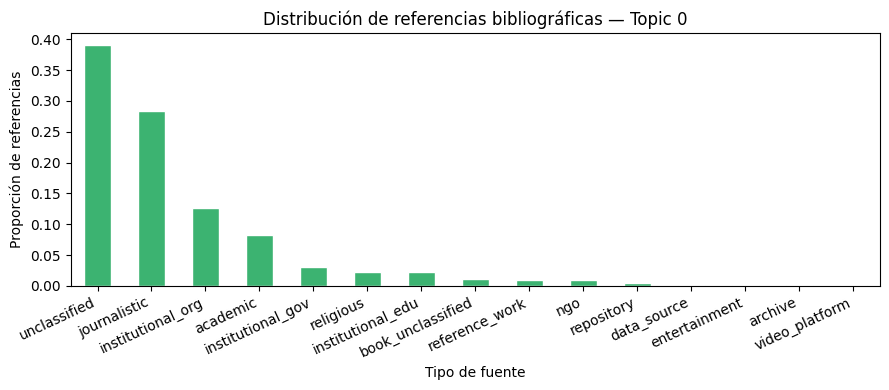

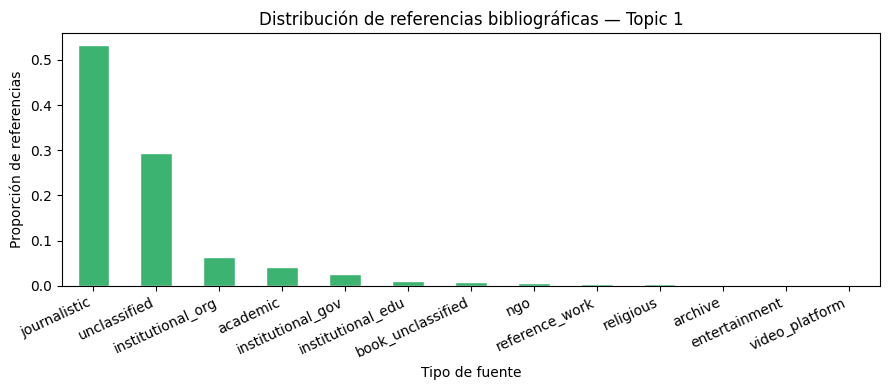

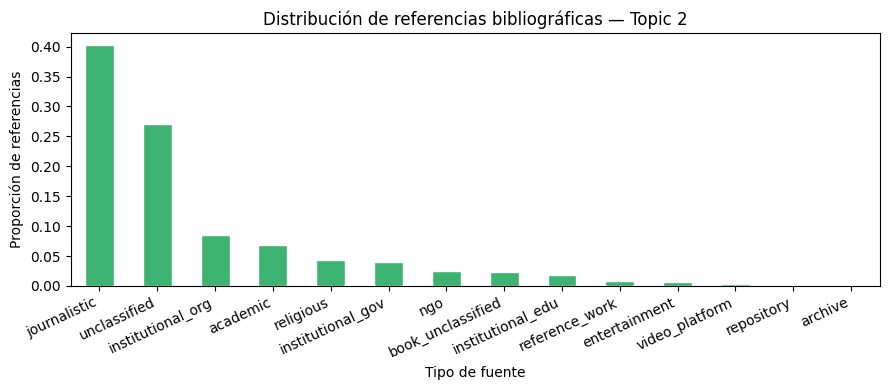

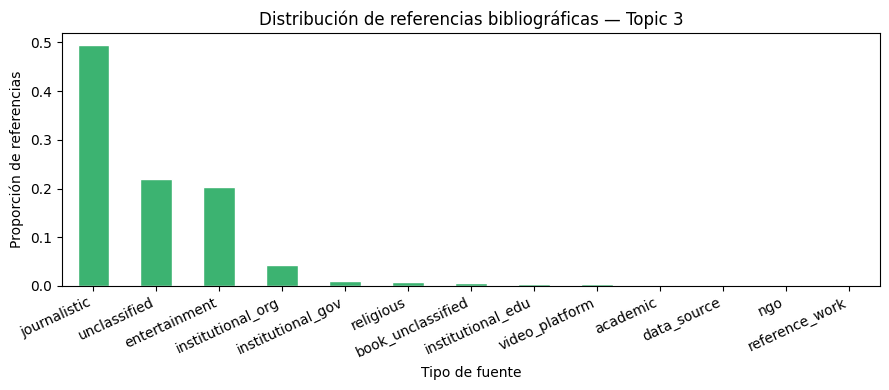

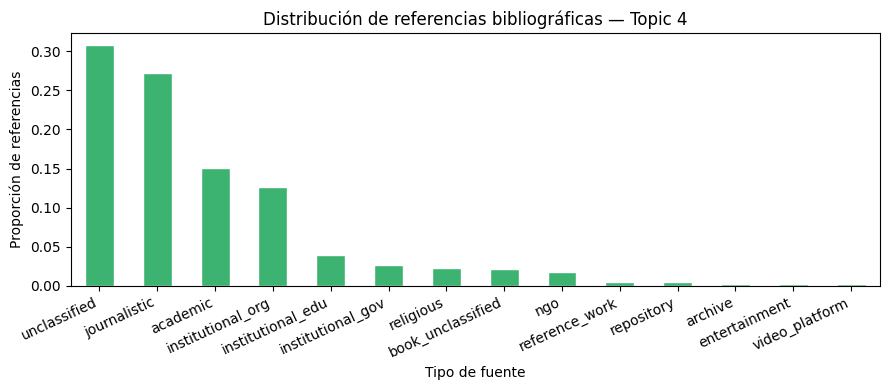

In [ ]:
for cluster in CLUSTER_ORDER:
    data = summary_cluster_norm.loc[cluster]
    data = data[data > 0]

    fig, ax = plt.subplots(figsize=(9, 4))
    data.sort_values(ascending=False).plot(kind="bar", ax=ax, color="mediumseagreen", edgecolor="white")
    ax.set_title(f"Distribución de referencias bibliográficas — {TOPIC_LABELS[cluster]}")
    ax.set_xlabel("Tipo de fuente")
    ax.set_ylabel("Proporción de referencias")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

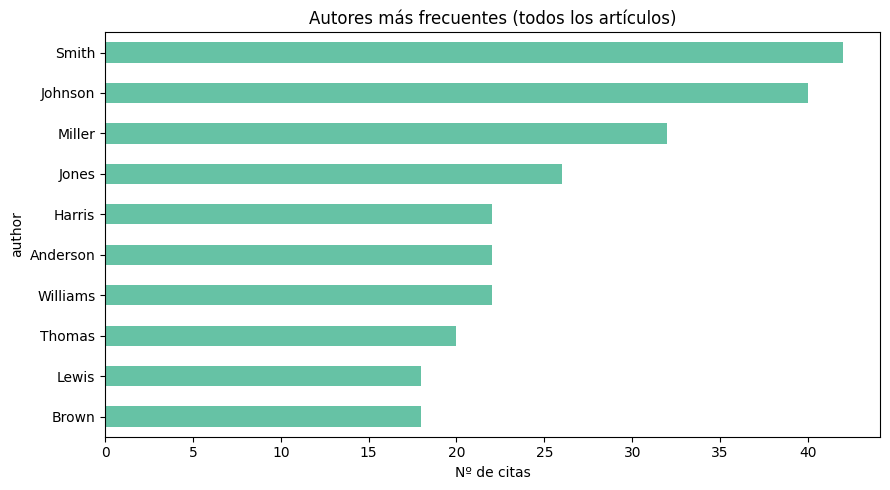

In [ ]:
data = article_refs["author"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
data.plot(kind="barh", ax=ax, colormap="Set2")
ax.set_title("Autores más frecuentes (todos los artículos)")
ax.set_xlabel("Nº de citas")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

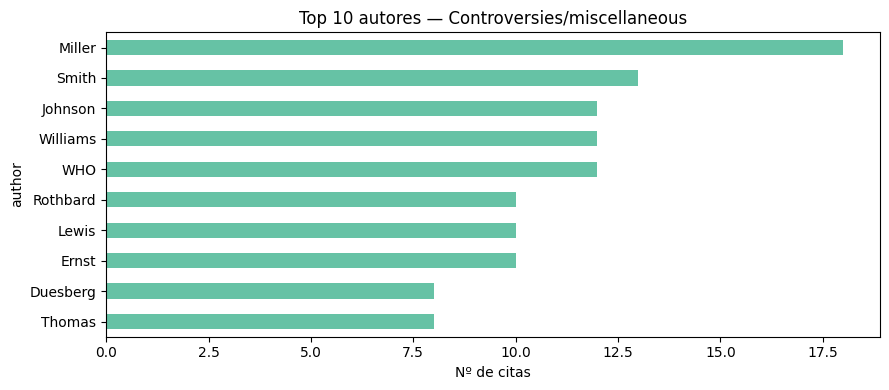

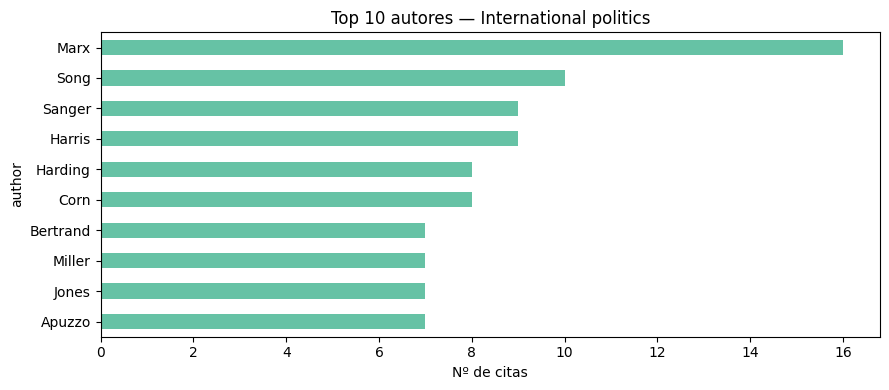

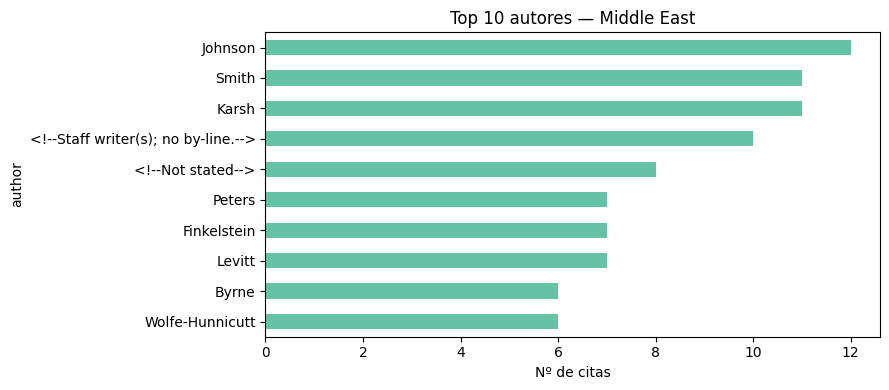

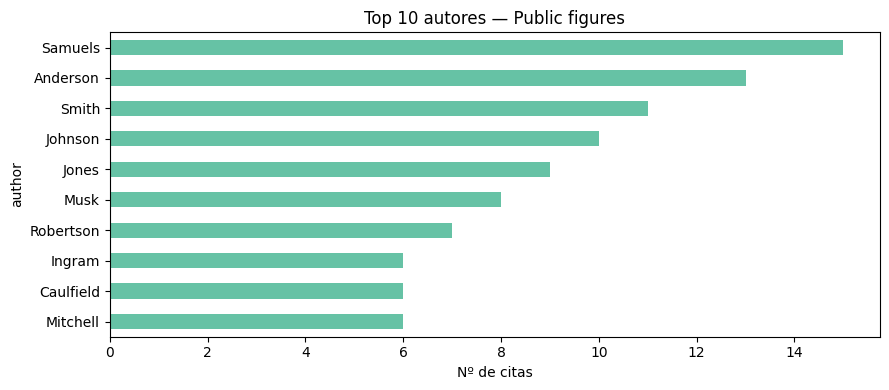

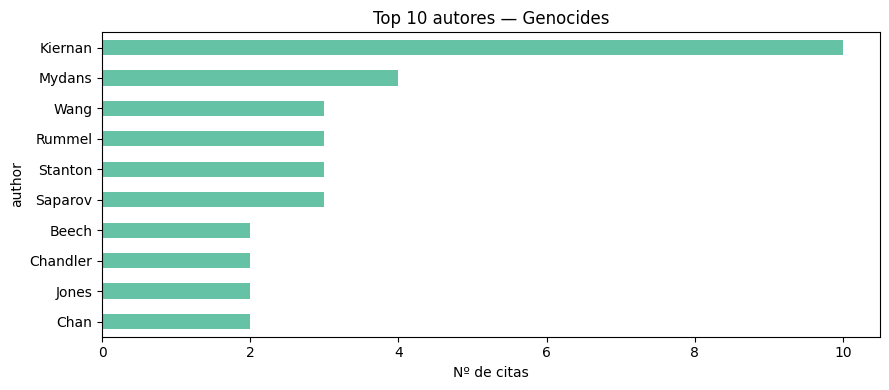

In [ ]:
for cluster in CLUSTER_ORDER:
    data = article_refs[article_refs["topic_title"] == cluster]["author"].value_counts().head(10)
    if data.empty:
        continue

    fig, ax = plt.subplots(figsize=(9, 4))
    data.plot(kind="barh", ax=ax, colormap="Set2")
    ax.set_title(f"Top 10 autores — {cluster}")
    ax.set_xlabel("Nº de citas")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

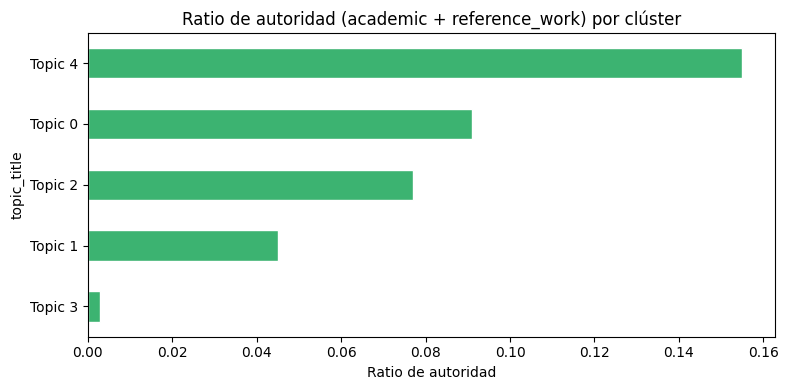

topic_title
Controversies/miscellaneous    0.091
International politics         0.045
Middle East                    0.077
Public figures                 0.003
Genocides                      0.155


In [ ]:
HIGH_AUTHORITY_CATEGORIES = {"academic", "reference_work"}

authority_ratio_cluster = (
    summary_cluster.reindex(columns=HIGH_AUTHORITY_CATEGORIES, fill_value=0).sum(axis=1)
    / summary_cluster.sum(axis=1)
).round(3).reindex(CLUSTER_ORDER)

fig, ax = plt.subplots(figsize=(8, 4))
authority_ratio_cluster.rename(index=TOPIC_LABELS).sort_values().plot(
    kind="barh", ax=ax, color="mediumseagreen", edgecolor="white"
)
ax.set_title("Ratio de autoridad (academic + reference_work) por clúster")
ax.set_xlabel("Ratio de autoridad")
plt.tight_layout()
plt.show()

print(authority_ratio_cluster.to_string())

#Maintenance templates

In [ ]:
HEADERS = {"User-Agent": "BiasAnalysis/1.0 (research project; contact: candela.welsh@outlook.com)"}

MAINTENANCE_TEMPLATES = {
    "Template:Unreferenced", "Template:No references",
    "Template:More citations needed", "Template:Better source needed",
    "Template:Unreliable sources", "Template:Third-party",
    "Template:Disputed", "Template:Disputed statement", "Template:Contradict",
    "Template:POV", "Template:Neutrality",
    "Template:Original research", "Template:Hoax",
    "Template:Page needed", "Template:Citation needed",
}

def get_maintenance_templates(page_id):
    r = requests.get(
        "https://en.wikipedia.org/w/api.php",
        params={"action": "query", "pageids": str(page_id), "prop": "templates",
                "tllimit": "500", "format": "json"},
        headers=HEADERS, timeout=10,
    )
    page = r.json()["query"]["pages"][str(page_id)]
    if "templates" not in page:
        return []
    return [t["title"] for t in page["templates"] if t["title"] in MAINTENANCE_TEMPLATES]

results_m3 = []
for _, row in df.iterrows():
    active_templates = get_maintenance_templates(row["id"])
    results_m3.append({
        "title": row["title"],
        "page_id": row["id"],
        "active_maintenance_templates": active_templates,
        "n_maintenance_templates": len(active_templates),
    })
    time.sleep(0.5)

m3_df = pd.DataFrame(results_m3).merge(clusters[["title", "topic_title"]], on="title", how="left")
print(m3_df[["title", "topic_title", "n_maintenance_templates"]].to_string())

                                                       title                  topic_title  n_maintenance_templates
0                                                   Abortion  Controversies/miscellaneous                        1
1                                         Anarcho-capitalism  Controversies/miscellaneous                        1
2                                                   Al-Qaeda                  Middle East                        2
3                                          Mikhail Gorbachev       International politics                        0
4                                                  Mormonism  Controversies/miscellaneous                        1
5                                                       NATO                  Middle East                        1
6                      Native Americans in the United States  Controversies/miscellaneous                        3
7                                    Politics of North Korea                  Mi

In [11]:
listado = m3_df[["title", "topic_title", "active_maintenance_templates"]].copy()
listado["plantillas"] = listado["active_maintenance_templates"].apply(
    lambda lst: ", ".join(t.replace("Template:", "") for t in lst) if lst else "None"
)
print(listado[["title", "topic_title", "plantillas"]].to_string(index=False))

                                                   title                 topic_title                                                                plantillas
                                                Abortion Controversies/miscellaneous                                                           Citation needed
                                      Anarcho-capitalism Controversies/miscellaneous                                                      Better source needed
                                                Al-Qaeda                 Middle East                                  More citations needed, Original research
                                       Mikhail Gorbachev      International politics                                                                      None
                                               Mormonism Controversies/miscellaneous                                                           Citation needed
                                              

In [12]:
plantillas_largo = listado.explode("active_maintenance_templates").dropna(subset=["active_maintenance_templates"])
plantillas_largo["active_maintenance_templates"] = plantillas_largo["active_maintenance_templates"].str.replace("Template:", "")

# Más frecuente en general
print("── General ──")
print(plantillas_largo["active_maintenance_templates"].value_counts().to_string())

# Conteo completo por clúster (todas las plantillas, no solo la más frecuente)
conteo_cluster = (
    plantillas_largo.groupby(["topic_title", "active_maintenance_templates"])
    .size()
    .unstack(fill_value=0)
)
print("\n── Conteo por clúster ──")
print(conteo_cluster.to_string())

# Solo la plantilla más frecuente de cada clúster
top_por_cluster = conteo_cluster.idxmax(axis=1).rename("plantilla_mas_frecuente")
n_top_por_cluster = conteo_cluster.max(axis=1).rename("n")
print("\n── Plantilla más frecuente por clúster ──")
print(pd.concat([top_por_cluster, n_top_por_cluster], axis=1).to_string())

── General ──
active_maintenance_templates
Citation needed          44
Page needed              19
Better source needed     17
More citations needed     5
Original research         2
POV                       1

── Conteo por clúster ──
active_maintenance_templates  Better source needed  Citation needed  More citations needed  Original research  POV  Page needed
topic_title                                                                                                                    
Controversies/miscellaneous                      8               19                      2                  0    1            7
Genocides                                        2                4                      0                  0    0            2
International politics                           1                7                      1                  0    0            3
Middle East                                      5               13                      2                  2    0         

In [13]:
listado.to_csv("06b_plantillas_activas_por_articulo.csv", index=False, encoding="utf-8-sig")

##Visualization

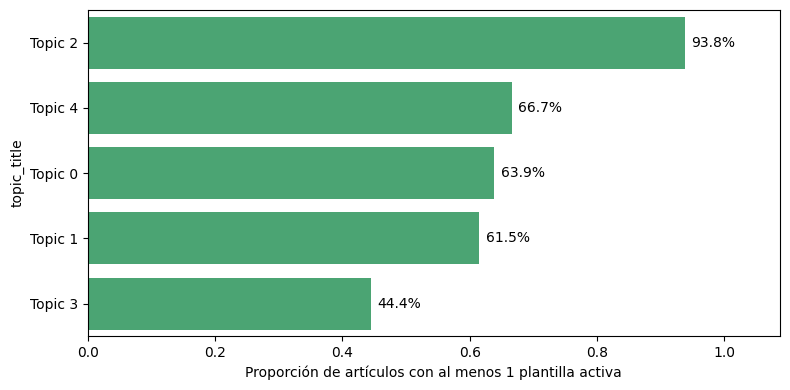

In [ ]:
flagged_ratio_cluster = (
    m3_df.assign(has_template=m3_df["n_maintenance_templates"] > 0)
    .groupby("topic_title")["has_template"]
    .mean()
    .rename(index=TOPIC_LABELS)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=flagged_ratio_cluster.values, y=flagged_ratio_cluster.index, color="mediumseagreen", ax=ax)
ax.set_xlabel("Proporción de artículos con al menos 1 plantilla activa")
ax.set_xlim(0, flagged_ratio_cluster.max() + 0.15)
for i, v in enumerate(flagged_ratio_cluster):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center")
plt.tight_layout()
plt.show()

## Saving data

In [ ]:
export_cols = [
    "article_title", "topic_title", "source_type_v3",
    "reference_url", "author", "reference_title", "publisher", "year",
    "is_book", "book_low_confidence",
]

export_df = article_refs[export_cols].copy()
export_df.to_csv("clasificacion_final_referencias.csv", index=False, encoding="utf-8-sig")
summary_cluster_norm.to_csv("resumen_por_cluster.csv", encoding="utf-8-sig")